# SDF_FC1 两种训练模式测试

这个 notebook 做两段测试：
1. 使用 `Sample.build_sdf_fc1_df()` 训练 SDF/FC1（`add_FC1loss=False`）并画预测 `M` 的分布。
2. 随机构造 `df_macro`，用 `build_sdf_pairs_from_macro_ts(df_macro)` 生成配对数据后，再做 `add_FC1loss=True` 的训练。

In [1]:
import sys
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'tests':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 保证可复现
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)


/Users/ballinliu/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/ballinliu/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


device = cpu


In [2]:
# 项目导入
from config import Config, HyperParams
from data import Sample
from data.data_utils import build_sdf_pairs_from_macro_ts
from training.episode import Episode
from experiments.run_utils import build_models, build_optimizers

Config.DEVICE = device

models = build_models(device)
optimizers = build_optimizers(models)

hp = HyperParams(
    epochs=100,
    batch_size=256,
    n_samples=4000,
    n_paths=2000,
)
hp.lr = 1e-3
hp.min_lr = 1e-6
hp.max_steps = 10000
hp.fc1_recon_weight = 1.0  # 第二阶段 add_FC1loss=True 时会用到

episode = Episode(
    models=models,
    optimizers=optimizers,
    config=Config,
    hyperparams=hp,
    device=device,
    episode_id=0,
)
print('models initialized:', list(models.keys()))

# 稳定版阶段参数
hp.sdf_stage1_lr = 1e-4
hp.sdf_stage1_moment_weight = 5.0
hp.sdf_moment_weight = 1.0


models initialized: ['sdf_fc1', 'policy_value', 'fc2']


In [3]:
# 诊断可视化：M、Δhatc、Δlnk

def _safe_np(x: torch.Tensor):
    return x.detach().cpu().numpy().reshape(-1)


def plot_pred_delta_distributions(df_sdf_like: pd.DataFrame, tag: str):
    required = ['x_t', 'x_t1', 'Hatcf_t', 'LnKF_t']
    missing = [c for c in required if c not in df_sdf_like.columns]
    if missing:
        raise ValueError(f"{tag}: missing columns {missing}")

    x_prev = torch.tensor(df_sdf_like['x_t'].values, device=device, dtype=torch.float32)
    x_curr = torch.tensor(df_sdf_like['x_t1'].values, device=device, dtype=torch.float32)
    hatcf_prev = torch.tensor(df_sdf_like['Hatcf_t'].values, device=device, dtype=torch.float32)
    lnkf_prev = torch.tensor(df_sdf_like['LnKF_t'].values, device=device, dtype=torch.float32)

    with torch.no_grad():
        _, _, M_pred, hatcf_curr, lnkf_curr = models['sdf_fc1'].forward_step(
            x_prev=x_prev,
            x_curr=x_curr,
            hatcf_prev=hatcf_prev,
            lnkf_prev=lnkf_prev,
            return_physical=True,
        )

    M_np = _safe_np(M_pred)
    d_hatcf_np = _safe_np(hatcf_curr.squeeze(-1) - hatcf_prev)
    d_lnkf_np = _safe_np(lnkf_curr.squeeze(-1) - lnkf_prev)

    def _finite_ratio(arr):
        return float(np.isfinite(arr).mean())

    print(f"[{tag}] M mean/std/min/max = {M_np.mean():.6g}, {M_np.std():.6g}, {M_np.min():.6g}, {M_np.max():.6g}")
    print(f"[{tag}] Δhatc mean/std = {d_hatcf_np.mean():.6g}, {d_hatcf_np.std():.6g}, finite={_finite_ratio(d_hatcf_np):.3f}")
    print(f"[{tag}] Δlnk  mean/std = {d_lnkf_np.mean():.6g}, {d_lnkf_np.std():.6g}, finite={_finite_ratio(d_lnkf_np):.3f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].hist(M_np[np.isfinite(M_np)], bins=40)
    axes[0].set_title(f'{tag}: Predicted M')
    axes[0].set_xlabel('M')

    axes[1].hist(d_hatcf_np[np.isfinite(d_hatcf_np)], bins=40)
    axes[1].set_title(f'{tag}: Δhatc (pred)')
    axes[1].set_xlabel('Δhatc')

    axes[2].hist(d_lnkf_np[np.isfinite(d_lnkf_np)], bins=40)
    axes[2].set_title(f'{tag}: Δlnk (pred)')
    axes[2].set_xlabel('Δlnk')

    for ax in axes:
        ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

    # mode2 数据若存在真实跨期列，也画真值分布用于对照
    true_cols = {'Hatc_t', 'Hatc_t1', 'LnK_t', 'LnK_t1'}
    if true_cols.issubset(set(df_sdf_like.columns)):
        d_hatc_true = (df_sdf_like['Hatc_t1'] - df_sdf_like['Hatc_t']).to_numpy()
        d_lnk_true = (df_sdf_like['LnK_t1'] - df_sdf_like['LnK_t']).to_numpy()

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].hist(d_hatc_true[np.isfinite(d_hatc_true)], bins=40)
        axes[0].set_title(f'{tag}: Δhatc (true)')
        axes[0].set_xlabel('Δhatc true')
        axes[0].set_ylabel('Count')

        axes[1].hist(d_lnk_true[np.isfinite(d_lnk_true)], bins=40)
        axes[1].set_title(f'{tag}: Δlnk (true)')
        axes[1].set_xlabel('Δlnk true')
        axes[1].set_ylabel('Count')

        plt.tight_layout()
        plt.show()

    return {
        'M': M_np,
        'delta_hatc_pred': d_hatcf_np,
        'delta_lnk_pred': d_lnkf_np,
    }


def report_nan_in_summary(summary: dict, name: str):
    final_losses = summary.get('final_losses', {}) if isinstance(summary, dict) else {}
    bad = {k: v for k, v in final_losses.items() if isinstance(v, float) and (np.isnan(v) or np.isinf(v))}
    if bad:
        print(f'[WARN] {name} has NaN/Inf in final_losses:', bad)
    else:
        print(f'[OK] {name} final_losses are finite.')


## 1) 模式一：Sample.build_sdf_fc1_df() + add_FC1loss=False

In [4]:
sampler = Sample(
    models=models,
    config=Config,
    n_samples=hp.n_samples,
    n_paths=hp.n_paths,
    group_size=2,
    branch_num=Config.BRANCH_NUM,
)

df_sdf = sampler.build_sdf_fc1_df()
print('df_sdf shape =', df_sdf.shape)
df_sdf.head()


Generating sdf_fc1 data: 100%|██████████| 666/666 [00:00<00:00, 17150.40it/s]

df_sdf shape = (1332, 6)


,path,branch,x_t,x_t1,Hatcf_t,LnKF_t
0,0,0,-2.002347,-2.015026,-1.912310,3.981869
1,0,1,-2.002347,-1.998750,-1.912310,3.981869
2,1,0,-2.005826,-1.999415,-1.964425,3.951976
3,1,1,-2.005826,-2.022027,-1.964425,3.951976
4,2,0,-1.985374,-1.960219,-1.982875,4.213494


In [5]:
episode.add_FC1loss = False

batches_mode1 = episode._create_sdf_batches_from_macro_df(
    df_sdf,
    batch_size=hp.batch_size,
    n_branches=Config.BRANCH_NUM,
)
print('num batches (mode1) =', len(batches_mode1))

summary_mode1 = episode._run_batches(
    batches=batches_mode1,
    n_epochs=hp.epochs,
    log_interval=20,
    train_modules=['sdf_fc1'],
    desc_prefix='Mode1 SDF/FC1 '
)
print('mode1 summary =', summary_mode1)


num batches (mode1) = 3


Mode1 SDF/FC1 Epoch 100/100: 100%|██████████| 3/3 [00:00<00:00, 288.04it/s]

mode1 summary = {'final_losses': {'sdf': 0.23540719226002693, 'sdf_main_loss': 0.0035351907523969808, 'sdf_moment_loss': 0.0463743987493217, 'sdf_moment_weight': 5.0, 'sdf_recon_loss': 0.0, 'sdf_log_mean_M': 0.012334173855682215, 'sdf_log_var_M': -4.015502214431763, 'sdf_dhatcf_mean': -0.435457577308019, 'sdf_dhatcf_p10': -0.49955366055170697, 'sdf_dhatcf_p50': -0.4366251627604167, 'sdf_dhatcf_p90': -0.368423730134964, 'sdf_dlnkf_mean': -0.44541363914807636, 'sdf_dlnkf_p10': -0.4669156273206075, 'sdf_dlnkf_p50': -0.44610917568206787, 'sdf_dlnkf_p90': -0.4223489463329315, 'total': 0.23540719226002693, 'sdf_fc1_grad_norm': 1199.4473484540842}}


[Mode1] M mean/std/min/max = 0.99666, 0.132995, 0.629491, 1.56339
[Mode1] Δhatc mean/std = -0.436839, 0.0504609, finite=1.000
[Mode1] Δlnk  mean/std = -0.442638, 0.0177507, finite=1.000


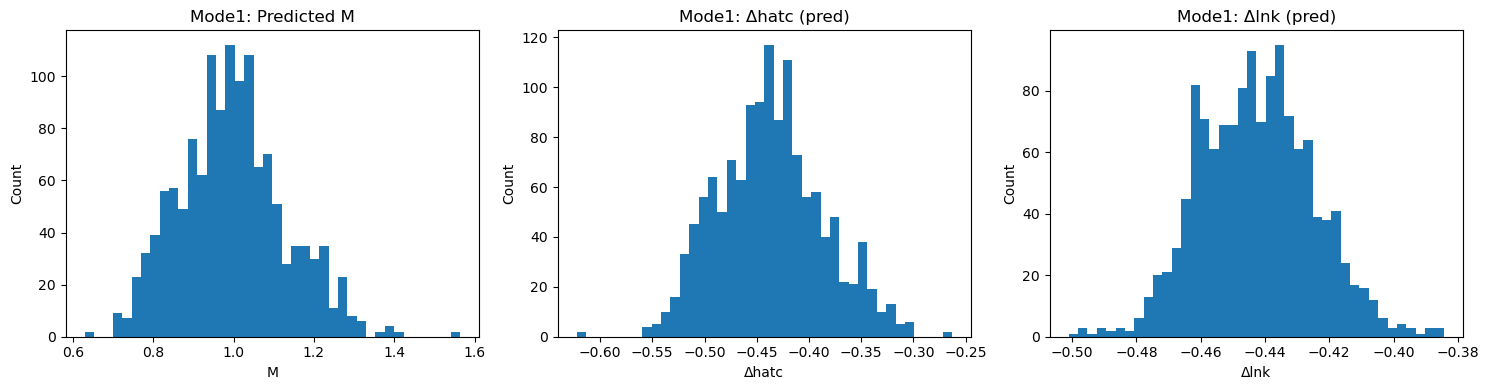

In [6]:
# Mode1 可视化：M + Δhatc + Δlnk
mode1_diag = plot_pred_delta_distributions(df_sdf, tag='Mode1')


## 2) 模式二：随机 df_macro -> build_sdf_pairs_from_macro_ts -> add_FC1loss=True

In [7]:
def make_random_macro_df(n_paths=64, horizon=4, branch_num=2):
    rows = []
    for path in range(n_paths):
        # 初始 parent 状态
        x_t = np.random.normal(loc=Config.XBAR, scale=Config.SIGMA_X)
        hatcf_t = np.random.normal(loc=-2.0, scale=0.15)
        lnkf_t = np.random.normal(loc=4.0, scale=0.25)
        hatc_t = np.random.normal(loc=-2.0, scale=0.15)
        lnk_t = np.random.normal(loc=4.0, scale=0.25)

        for t in range(horizon):
            # parent 行 (branch=-1)
            rows.append({
                'path': path,
                't': t,
                'branch': -1,
                'x': float(x_t),
                'hatcf': float(hatcf_t),
                'lnkf': float(lnkf_t),
                'Hatc': float(hatc_t),
                'LnK': float(lnk_t),
            })

            # child 行 (branch=0..branch_num-1) at t+1
            for b in range(branch_num):
                x_t1 = Config.RHO_X * x_t + (1 - Config.RHO_X) * Config.XBAR + np.random.normal(0, Config.SIGMA_X)
                hatc_t1 = hatc_t + np.random.normal(0, 0.05)
                lnk_t1 = lnk_t + np.random.normal(0, 0.05)

                rows.append({
                    'path': path,
                    't': t + 1,
                    'branch': b,
                    'x': float(x_t1),
                    'hatcf': float(hatcf_t),
                    'lnkf': float(lnkf_t),
                    'Hatc': float(hatc_t1),
                    'LnK': float(lnk_t1),
                })

            # 主分支推进（这里只是构造数据，不追求经济一致性）
            x_t = Config.RHO_X * x_t + (1 - Config.RHO_X) * Config.XBAR + np.random.normal(0, Config.SIGMA_X)
            hatcf_t = hatcf_t + np.random.normal(0, 0.05)
            lnkf_t = lnkf_t + np.random.normal(0, 0.05)
            hatc_t = hatc_t + np.random.normal(0, 0.05)
            lnk_t = lnk_t + np.random.normal(0, 0.05)

    return pd.DataFrame(rows)


df_macro = make_random_macro_df(n_paths=64, horizon=4, branch_num=Config.BRANCH_NUM)
print('df_macro shape =', df_macro.shape)
df_macro.head()


df_macro shape = (768, 8)


,path,t,branch,x,hatcf,lnkf,Hatc,LnK
0,0,0,-1,-1.994039,-2.020740,4.161922,-1.771546,3.941462
1,0,1,0,-1.997147,-2.020740,4.161922,-1.692585,3.979833
2,0,1,1,-1.999971,-2.020740,4.161922,-1.744418,3.918291
3,0,1,-1,-1.999926,-2.008642,4.066258,-1.857791,3.913347
4,0,2,0,-2.012084,-2.008642,4.066258,-1.842079,3.867946


In [8]:
df_sdf_mode2 = build_sdf_pairs_from_macro_ts(df_macro, include_hatc_lnk_t1=True)
print('df_sdf_mode2 shape =', df_sdf_mode2.shape)
print('columns =', df_sdf_mode2.columns.tolist())
df_sdf_mode2.head()


df_sdf_mode2 shape = (512, 11)
columns = ['path', 't', 'branch', 'x_t', 'x_t1', 'Hatcf_t', 'LnKF_t', 'Hatc_t', 'LnK_t', 'Hatc_t1', 'LnK_t1']


,path,t,branch,x_t,x_t1,Hatcf_t,LnKF_t,Hatc_t,LnK_t,Hatc_t1,LnK_t1
0,0,1,0,-1.994039,-1.997147,-2.020740,4.161922,-1.771546,3.941462,-1.692585,3.979833
1,0,1,1,-1.994039,-1.999971,-2.020740,4.161922,-1.771546,3.941462,-1.744418,3.918291
2,0,2,0,-1.999926,-2.012084,-2.008642,4.066258,-1.857791,3.913347,-1.842079,3.867946
3,0,2,1,-1.999926,-2.016878,-2.008642,4.066258,-1.857791,3.913347,-1.784509,3.902058
4,0,3,0,-1.999120,-1.994655,-2.079879,4.039039,-1.852245,3.855798,-1.882277,3.841213


In [9]:
episode.add_FC1loss = True

batches_mode2 = episode._create_sdf_batches_from_macro_df(
    df_sdf_mode2,
    batch_size=hp.batch_size,
    n_branches=Config.BRANCH_NUM,
)
print('num batches (mode2) =', len(batches_mode2))

summary_mode2 = episode._run_batches(
    batches=batches_mode2,
    n_epochs=hp.epochs,
    log_interval=20,
    train_modules=['sdf_fc1'],
    desc_prefix='Mode2 SDF/FC1 '
)
print('mode2 summary =', summary_mode2)


num batches (mode2) = 1


Mode2 SDF/FC1 Epoch 100/100: 100%|██████████| 1/1 [00:00<00:00, 231.49it/s]

mode2 summary = {'final_losses': {'sdf': 0.3063848912715912, 'sdf_main_loss': 0.00017711802502162755, 'sdf_moment_loss': 0.10772895812988281, 'sdf_moment_weight': 1.0, 'sdf_recon_loss': 0.1984788179397583, 'sdf_log_mean_M': 0.023205962032079697, 'sdf_log_var_M': -4.597465991973877, 'sdf_dhatcf_mean': 0.010542246513068676, 'sdf_dhatcf_p10': -0.03562576696276665, 'sdf_dhatcf_p50': 0.00959080457687378, 'sdf_dhatcf_p90': 0.0646277666091919, 'sdf_dlnkf_mean': -0.05046159401535988, 'sdf_dlnkf_p10': -0.08609328418970108, 'sdf_dlnkf_p50': -0.051688313484191895, 'sdf_dlnkf_p90': -0.018164707347750664, 'total': 0.3063848912715912, 'sdf_fc1_grad_norm': 444.16788203941235}}


[Mode2] M mean/std/min/max = 0.994731, 0.098543, 0.760936, 1.27365
[Mode2] Δhatc mean/std = 0.00460077, 0.0423545, finite=1.000
[Mode2] Δlnk  mean/std = -0.048346, 0.0299301, finite=1.000


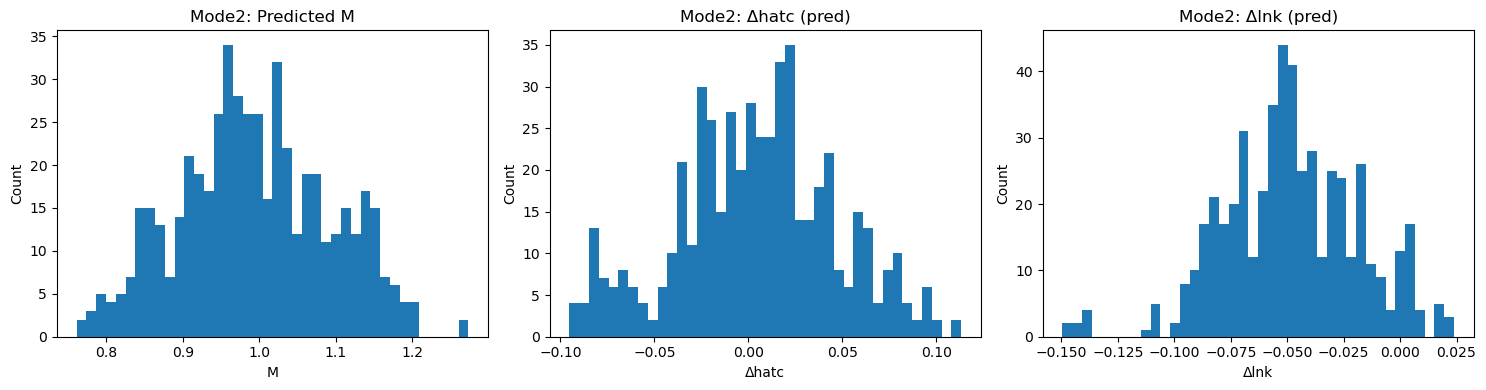

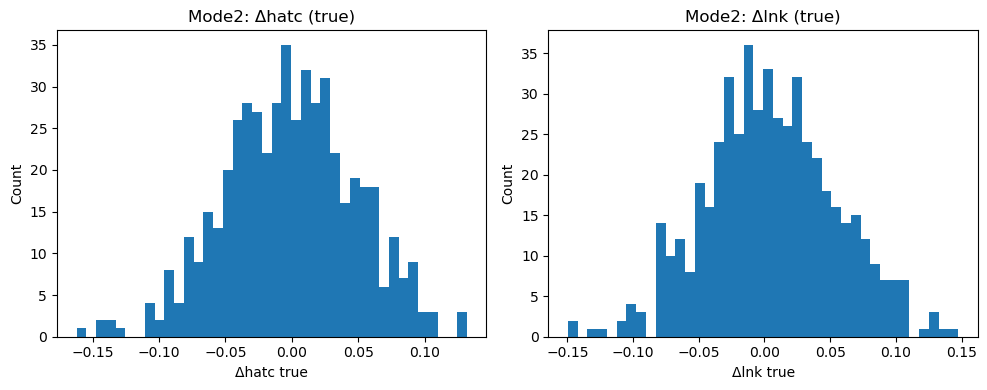

In [10]:
# Mode2 可视化：M + Δhatc + Δlnk（含 true 对照列时会自动绘制）
mode2_diag = plot_pred_delta_distributions(df_sdf_mode2, tag='Mode2')


In [11]:
print('Done. 两种模式都跑完。')
print('Mode1 final:', summary_mode1)
print('Mode2 final:', summary_mode2)
report_nan_in_summary(summary_mode1, 'Mode1')
report_nan_in_summary(summary_mode2, 'Mode2')


Done. 两种模式都跑完。
Mode1 final: {'final_losses': {'sdf': 0.23540719226002693, 'sdf_main_loss': 0.0035351907523969808, 'sdf_moment_loss': 0.0463743987493217, 'sdf_moment_weight': 5.0, 'sdf_recon_loss': 0.0, 'sdf_log_mean_M': 0.012334173855682215, 'sdf_log_var_M': -4.015502214431763, 'sdf_dhatcf_mean': -0.435457577308019, 'sdf_dhatcf_p10': -0.49955366055170697, 'sdf_dhatcf_p50': -0.4366251627604167, 'sdf_dhatcf_p90': -0.368423730134964, 'sdf_dlnkf_mean': -0.44541363914807636, 'sdf_dlnkf_p10': -0.4669156273206075, 'sdf_dlnkf_p50': -0.44610917568206787, 'sdf_dlnkf_p90': -0.4223489463329315, 'total': 0.23540719226002693, 'sdf_fc1_grad_norm': 1199.4473484540842}}
Mode2 final: {'final_losses': {'sdf': 0.3063848912715912, 'sdf_main_loss': 0.00017711802502162755, 'sdf_moment_loss': 0.10772895812988281, 'sdf_moment_weight': 1.0, 'sdf_recon_loss': 0.1984788179397583, 'sdf_log_mean_M': 0.023205962032079697, 'sdf_log_var_M': -4.597465991973877, 'sdf_dhatcf_mean': 0.010542246513068676, 'sdf_dhatcf_p10':

## 3) Policy & Value 测试（接续 SDF 测试）

In [12]:
from data import SimulateTS

# Policy/Value 测试使用独立一套模型，避免和前面 SDF 流程互相污染
pv_models = models
pv_optimizers = build_optimizers(pv_models)

hp_pv = HyperParams(
    epochs=30,
    batch_size=256,
    n_samples=None,
    n_paths=2000,
)
hp_pv.lr = 1e-3
hp_pv.min_lr = 1e-6
hp_pv.max_steps = 10000

# Q 优先训练（先训 Q，再联合）
hp_pv.q_pretrain_epochs = 10
hp_pv.q_use_detached_m = True
hp_pv.q_m_clamp_min = 0.5
hp_pv.q_m_clamp_max = 1.5
hp_pv.q_shape_weight_z = 1.0
hp_pv.q_shape_weight_b_low = 1.0
hp_pv.q_shape_weight_b_high = 1.0
hp_pv.q_shape_b_low = 0.2
hp_pv.q_shape_b_high = 0.8

hp_pv.q_freeze_non_q_in_pretrain = True
hp_pv.q_pretrain_trainable_scope = "q_head_only"


hp_pv.q_warmstart_epochs = 10
hp_pv.q_warmstart_weight = 1.0
hp_pv.q_warm_A = 1.0
hp_pv.q_warm_b_star = 0.05
hp_pv.q_warm_sigma = 0.15
hp_pv.q_warm_alpha_z = 0.15
hp_pv.q_warm_alpha_x = 0.15

episode_pv = Episode(
    models=pv_models,
    optimizers=pv_optimizers,
    config=Config,
    hyperparams=hp_pv,
    device=device,
    episode_id=0,
)

print('policy test models initialized:', list(pv_models.keys()))



policy test models initialized: ['sdf_fc1', 'policy_value', 'fc2']


In [13]:
def plot_policy_outputs(df_firm: pd.DataFrame, tag: str):
    input_cols = ['b', 'z', 'ETA', 'i', 'x', 'Hatcf', 'LnKF']
    missing = [c for c in input_cols if c not in df_firm.columns]
    if missing:
        raise ValueError(f"{tag}: missing columns {missing}")

    if 't' in df_firm.columns and df_firm['t'].dtype == object:
        parent_df = df_firm[df_firm['t'] == 't'].copy()
    elif 'branch' in df_firm.columns:
        parent_df = df_firm[df_firm['branch'] <= 0].copy()
    else:
        parent_df = df_firm.copy()

    X = torch.tensor(parent_df[input_cols].values, device=device, dtype=torch.float32)
    with torch.no_grad():
        out = pv_models['policy_value'](X)

    stats = {
        'Q': out.Q.detach().cpu().numpy().reshape(-1),
        'P0': out.P0.detach().cpu().numpy().reshape(-1),
        'PI': out.PI.detach().cpu().numpy().reshape(-1),
        'bp': out.bp.detach().cpu().numpy().reshape(-1),
        'bar_i': out.bar_i.detach().cpu().numpy().reshape(-1),
        'bar_z': out.bar_z.detach().cpu().numpy().reshape(-1),
    }

    print(f'[{tag}] parent rows =', len(parent_df))
    for k, arr in stats.items():
        finite = np.isfinite(arr)
        print(f'[{tag}] {k}: mean={arr[finite].mean():.6g}, std={arr[finite].std():.6g}, finite_ratio={finite.mean():.3f}')

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, (k, arr) in zip(axes.ravel(), stats.items()):
        arr_f = arr[np.isfinite(arr)]
        ax.hist(arr_f, bins=40)
        ax.set_title(f'{tag}: {k}')
        ax.set_xlabel(k)
        ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

    return stats


### 3.1 Mode1（Sample 截面三元组）

In [14]:
sampler_pv = Sample(
    models=pv_models,
    config=Config,
    n_samples=hp_pv.n_samples,
    n_paths=hp_pv.n_paths,
    group_size=2,
    branch_num=Config.BRANCH_NUM,
)

df_pv_mode1 = sampler_pv.build_policy_value_df()
print('df_pv_mode1 shape =', df_pv_mode1.shape)
df_pv_mode1.head()


Generating sample data: 100%|██████████| 2000/2000 [00:02<00:00, 998.02it/s] 


df_pv_mode1 shape = (12000, 14)


,path,ID,t,branch,b,z,ETA,i,x,Hatcf,LnKF,M,K,Entry
0,0,573c93b114fe4fe58037f3a440713c40,t,0,0.860194,0.555898,0.0,0.101278,-1.969638,-2.059119,4.182689,1.000000,1.0,1
1,0,573c93b114fe4fe58037f3a440713c40,t+1_0,1,0.860194,0.919203,0.0,0.383286,-1.952291,-2.092551,4.137144,0.895559,1.0,0
2,0,573c93b114fe4fe58037f3a440713c40,t+1_1,2,0.860194,0.397901,0.0,0.182024,-1.962031,-2.092641,4.136667,0.892591,1.0,0
3,0,4601ce97020e4a3e8430b6804ed595f1,t,0,0.452892,0.918442,0.0,0.172569,-1.969638,-2.059119,4.182689,1.000000,1.0,1
4,0,4601ce97020e4a3e8430b6804ed595f1,t+1_0,1,0.452892,1.300194,0.0,0.412862,-1.952291,-2.092551,4.137144,0.895559,1.0,0


In [15]:
pv_batches_mode1 = episode_pv._create_firm_batches_from_df(
    df_pv_mode1,
    batch_size=hp_pv.batch_size,
    n_branches=Config.BRANCH_NUM,
)
print('num pv batches (mode1) =', len(pv_batches_mode1))

episode_pv.loss_history = {}
summary_pv_mode1 = {}
pv_mode1_loss_history = {}
if len(pv_batches_mode1) > 0:
    summary_pv_mode1 = episode_pv._run_batches(
        batches=pv_batches_mode1,
        n_epochs=hp_pv.epochs,
        log_interval=20,
        train_modules=['policy_value'],
        desc_prefix='PV Mode1 '
    )
    pv_mode1_loss_history = {k: list(v) for k, v in episode_pv.loss_history.items()}
    print('summary_pv_mode1 =', summary_pv_mode1)
    report_nan_in_summary(summary_pv_mode1, 'PV Mode1')
else:
    print('[WARN] PV Mode1 has 0 batches, skip training.')



num pv batches (mode1) = 16


PV Mode1 Epoch 30/30: 100%|██████████| 16/16 [00:01<00:00, 11.06it/s]

summary_pv_mode1 = {'final_losses': {'p0': 0.018020235613221303, 'p0_main': 0.0100316526950337, 'p0_foc': 0.00017620640574023128, 'p0_penalty_z': 0.007757197090541013, 'p0_penalty_z_foc': 5.5179777419311904e-05, 'p0_cf_grad_abs_mean': 0.02161445131059736, 'p0_pgrad_abs_mean': 0.02419886994175613, 'p0_cf_grad_missing': 0.0, 'p0_cf_grad_missing_ratio': 0.0, 'p0_pgrad_missing_ratio': 0.0, 'pi': 0.07029951876029372, 'pi_main': 0.02703798469156027, 'pi_foc': 0.00021003874553571222, 'pi_penalty_z': 0.004938885133014992, 'pi_penalty_b': 0.038041552528738976, 'pi_penalty_z_foc': 7.105758668046747e-05, 'pi_cf_grad_abs_mean': 0.024291254521813244, 'pi_pgrad_abs_mean': 0.02443934592884034, 'pi_cf_grad_missing': 0.0, 'pi_cf_grad_missing_ratio': 0.0, 'pi_pgrad_missing_ratio': 0.0, 'q': 0.04061024950351566, 'q_main': 0.0077165933907963336, 'q_bdry_low': 0.00017483528563388973, 'q_bdry_high': 0.0005266652260615956, 'q_shape_z': 0.0, 'q_shape_b_low': 0.0, 'q_shape_b_high': 0.025461415245445096, 'q_phy

[PV Mode1] parent rows = 4000
[PV Mode1] Q: mean=0.26949, std=0.128748, finite_ratio=1.000
[PV Mode1] P0: mean=-0.330929, std=0.319146, finite_ratio=1.000
[PV Mode1] PI: mean=-0.511821, std=0.325458, finite_ratio=1.000
[PV Mode1] bp: mean=0.0333428, std=0.014799, finite_ratio=1.000
[PV Mode1] bar_i: mean=0.234008, std=0.264696, finite_ratio=1.000
[PV Mode1] bar_z: mean=0.798763, std=0.275843, finite_ratio=1.000


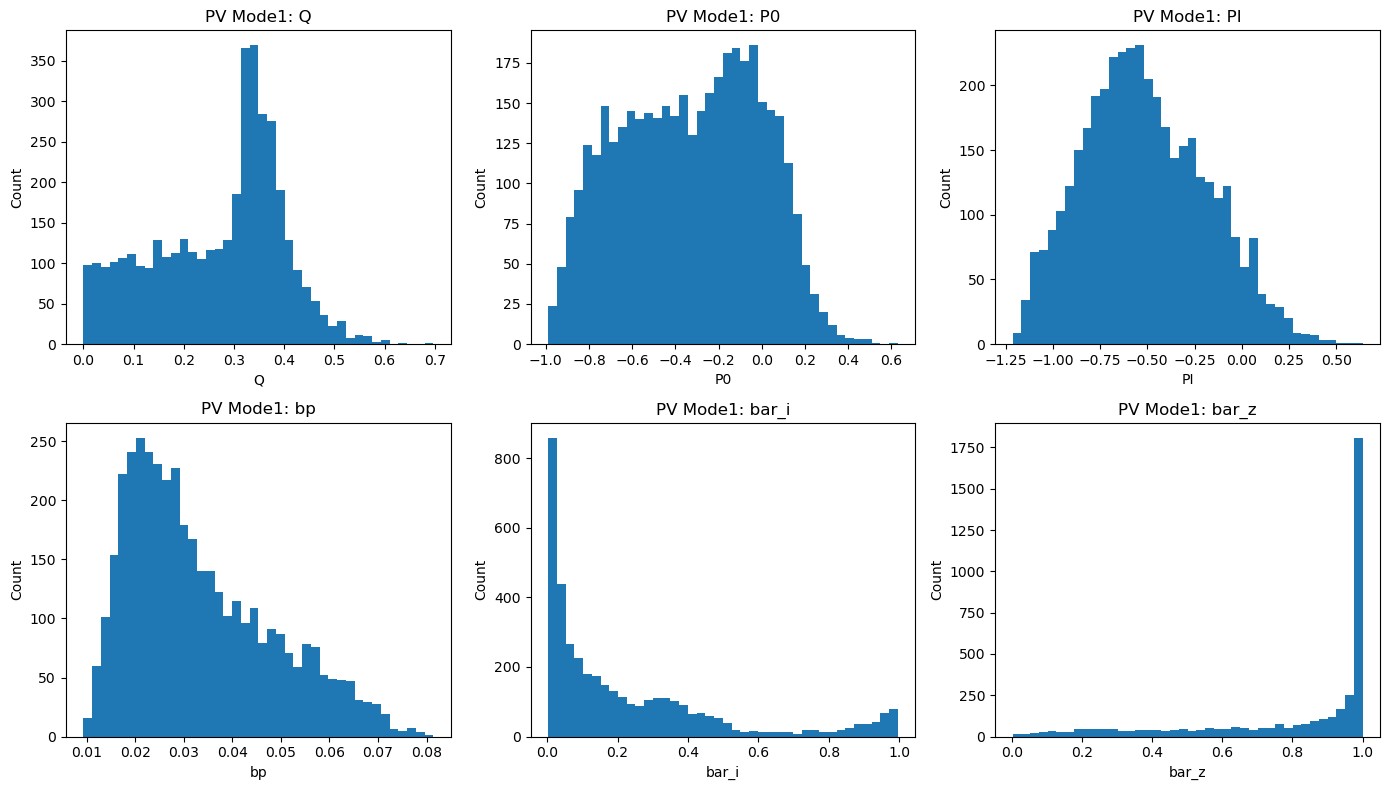

In [16]:
pv_mode1_stats = plot_policy_outputs(df_pv_mode1, tag='PV Mode1')


### 3.2 Mode2（SimulateTS 时序树数据）

In [17]:
from importlib import reload
import data.simulate_ts as simulate_ts_mod

# 防止 notebook 复跑时仍引用旧版 SimulateTS（尤其在代码刚修改后）
simulate_ts_mod = reload(simulate_ts_mod)
SimulateTS = simulate_ts_mod.SimulateTS

sim_pv = SimulateTS(
    models=pv_models,
    config=Config,
    n_paths=16,
    group_size=32,
    horizon=2,
    branch_num=Config.BRANCH_NUM,
    device=device,
)

df_pv_mode2, df_pv_macro_mode2 = sim_pv.simulate()
print('df_pv_mode2 shape =', df_pv_mode2.shape)
print('df_pv_macro_mode2 shape =', df_pv_macro_mode2.shape)
df_pv_mode2.head()

Simulating paths: 100%|██████████| 16/16 [00:00<00:00, 42.34it/s]


Simulation completed: 3170 firm records, 96 macro records
df_pv_mode2 shape = (3170, 27)
df_pv_macro_mode2 shape = (96, 12)


,path,t,branch,ID,entry,b,z,ETA,i,x,...,Bar_i,Bar_z,P,bp0,bpI,bp,Y,I,Phi,C
0,0,0,-1,98a20abd33db440180cf8c9e98772b69,1.0,0.934681,0.146447,0.0,0.289156,-2.057888,...,0.060581,0.997795,0.000935,0.070384,0.078916,0.070901,0.089960,-0.584217,0.418082,0.256095
1,0,0,-1,77277b9e0d9148109b7137baceeca3f5,1.0,0.616637,-1.160218,0.0,0.024528,-2.057888,...,0.291231,0.994849,0.001841,0.038670,0.059514,0.044741,0.035058,-0.847488,0.543682,0.338864
2,0,0,-1,f4da1cde06474689a3aaad69b3ac637b,1.0,0.203455,-0.703418,0.0,0.093807,-2.057888,...,0.257164,0.640795,0.061023,0.023091,0.044653,0.028636,0.031793,-0.300112,0.205607,0.126298
3,0,0,-1,9af00f8af5204c45aee62390c0b62f61,1.0,0.492446,-0.637780,0.0,0.345561,-2.057888,...,0.019198,0.975299,0.006435,0.035394,0.053734,0.035746,0.051356,-0.721797,0.475290,0.297864
4,0,0,-1,77abfdf8be4a47aea393904a58c6fe2c,1.0,0.805888,-0.978905,0.0,0.341091,-2.057888,...,0.058394,0.999140,0.000441,0.053227,0.066044,0.053975,0.007927,-0.158454,0.103781,0.062600


In [18]:
pv_batches_mode2 = episode_pv._create_firm_batches_from_df(
    df_pv_mode2,
    batch_size=hp_pv.batch_size,
    n_branches=Config.BRANCH_NUM,
)
print('num pv batches (mode2) =', len(pv_batches_mode2))

episode_pv.loss_history = {}
summary_pv_mode2 = {}
pv_mode2_loss_history = {}
if len(pv_batches_mode2) > 0:
    summary_pv_mode2 = episode_pv._run_batches(
        batches=pv_batches_mode2,
        n_epochs=hp_pv.epochs,
        log_interval=20,
        train_modules=['policy_value'],
        desc_prefix='PV Mode2 '
    )
    pv_mode2_loss_history = {k: list(v) for k, v in episode_pv.loss_history.items()}
    print('summary_pv_mode2 =', summary_pv_mode2)
    report_nan_in_summary(summary_pv_mode2, 'PV Mode2')
else:
    print('[WARN] PV Mode2 has 0 batches, skip training.')



num pv batches (mode2) = 3


PV Mode2 Epoch 30/30: 100%|██████████| 3/3 [00:00<00:00, 12.15it/s]

summary_pv_mode2 = {'final_losses': {'p0': 0.007087077014148235, 'p0_main': 0.004084742162376642, 'p0_foc': 0.00048024547868408263, 'p0_penalty_z': 0.002437075600028038, 'p0_penalty_z_foc': 8.501373546702477e-05, 'p0_cf_grad_abs_mean': 0.019781062689920265, 'p0_pgrad_abs_mean': 0.02534043788909912, 'p0_cf_grad_missing': 0.0, 'p0_cf_grad_missing_ratio': 0.0, 'p0_pgrad_missing_ratio': 0.0, 'pi': 0.07092064867417018, 'pi_main': 0.022610162074367206, 'pi_foc': 0.0005642630470295747, 'pi_penalty_z': 0.0026635804291193685, 'pi_penalty_b': 0.044995877891778946, 'pi_penalty_z_foc': 8.676728490778866e-05, 'pi_cf_grad_abs_mean': 0.022647124094267685, 'pi_pgrad_abs_mean': 0.0255487406005462, 'pi_cf_grad_missing': 0.0, 'pi_cf_grad_missing_ratio': 0.0, 'pi_pgrad_missing_ratio': 0.0, 'q': 0.03804123277465502, 'q_main': 0.006787124012286465, 'q_bdry_low': 0.0002963210960539679, 'q_bdry_high': 0.001324101195981105, 'q_shape_z': 0.00021272688657821467, 'q_shape_b_low': 0.0, 'q_shape_b_high': 0.02388909

[PV Mode2] parent rows = 1900
[PV Mode2] Q: mean=0.203745, std=0.110847, finite_ratio=1.000
[PV Mode2] P0: mean=-0.279113, std=0.358426, finite_ratio=1.000
[PV Mode2] PI: mean=-0.46536, std=0.323062, finite_ratio=1.000
[PV Mode2] bp: mean=0.0798465, std=0.0325285, finite_ratio=1.000
[PV Mode2] bar_i: mean=0.230197, std=0.251041, finite_ratio=1.000
[PV Mode2] bar_z: mean=0.74836, std=0.31937, finite_ratio=1.000


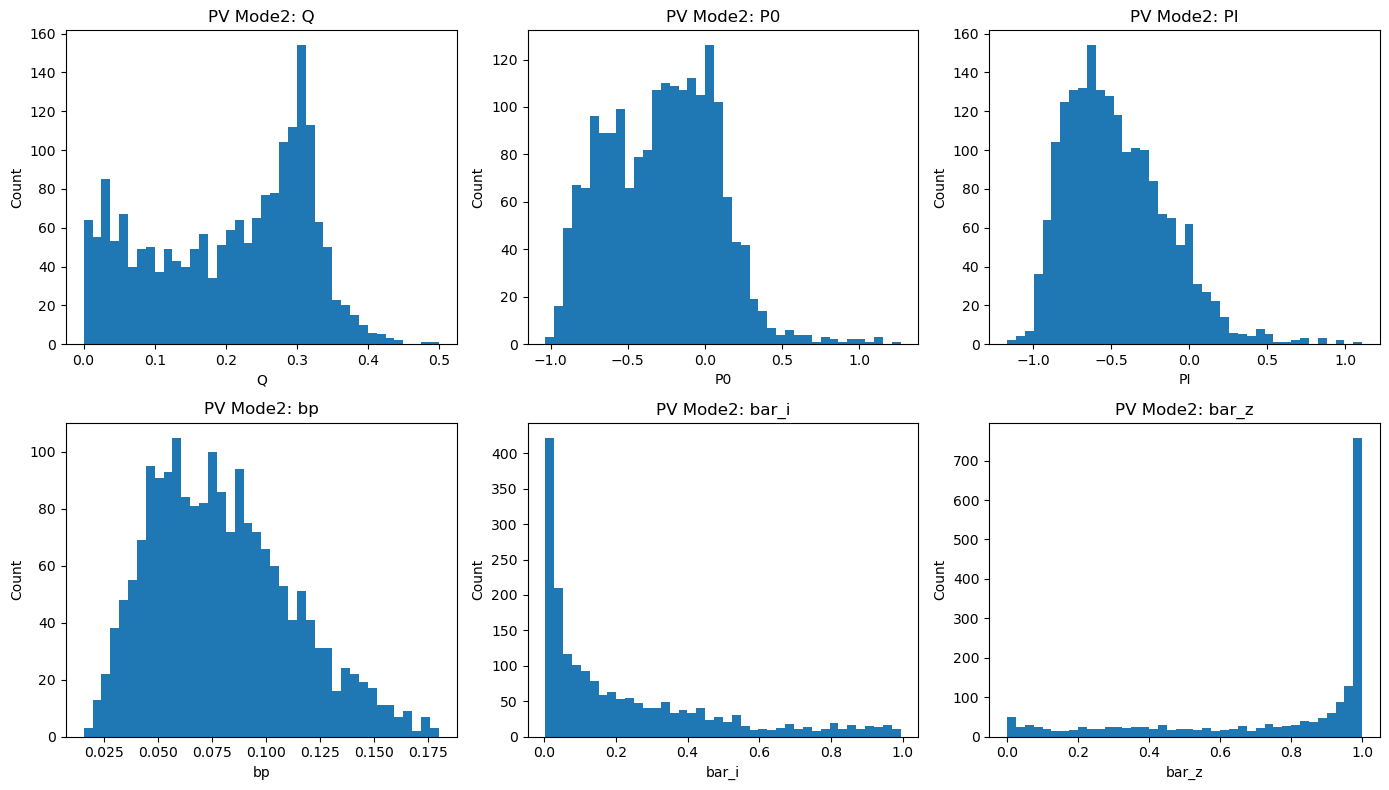

In [19]:
pv_mode2_stats = plot_policy_outputs(df_pv_mode2, tag='PV Mode2')


In [20]:
print('Policy & Value tests done.')
print('PV Mode1 final:', summary_pv_mode1 if 'summary_pv_mode1' in globals() else {})
print('PV Mode2 final:', summary_pv_mode2 if 'summary_pv_mode2' in globals() else {})



Policy & Value tests done.
PV Mode1 final: {'final_losses': {'p0': 0.018020235613221303, 'p0_main': 0.0100316526950337, 'p0_foc': 0.00017620640574023128, 'p0_penalty_z': 0.007757197090541013, 'p0_penalty_z_foc': 5.5179777419311904e-05, 'p0_cf_grad_abs_mean': 0.02161445131059736, 'p0_pgrad_abs_mean': 0.02419886994175613, 'p0_cf_grad_missing': 0.0, 'p0_cf_grad_missing_ratio': 0.0, 'p0_pgrad_missing_ratio': 0.0, 'pi': 0.07029951876029372, 'pi_main': 0.02703798469156027, 'pi_foc': 0.00021003874553571222, 'pi_penalty_z': 0.004938885133014992, 'pi_penalty_b': 0.038041552528738976, 'pi_penalty_z_foc': 7.105758668046747e-05, 'pi_cf_grad_abs_mean': 0.024291254521813244, 'pi_pgrad_abs_mean': 0.02443934592884034, 'pi_cf_grad_missing': 0.0, 'pi_cf_grad_missing_ratio': 0.0, 'pi_pgrad_missing_ratio': 0.0, 'q': 0.04061024950351566, 'q_main': 0.0077165933907963336, 'q_bdry_low': 0.00017483528563388973, 'q_bdry_high': 0.0005266652260615956, 'q_shape_z': 0.0, 'q_shape_b_low': 0.0, 'q_shape_b_high': 0.02

## 4) Policy/Value 训练后可视化

包含：loss 曲线、parent 的 bp 直方图、b-z-Q/P0/PI/P 的 3D 图与热力图。


In [21]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def _select_parent_df_for_pv(df_firm: pd.DataFrame) -> pd.DataFrame:
    if 't' in df_firm.columns and pd.api.types.is_string_dtype(df_firm['t']):
        return df_firm[df_firm['t'] == 't'].copy()
    if 't' in df_firm.columns and df_firm['t'].dtype == object:
        return df_firm[df_firm['t'] == 't'].copy()
    if 'branch' in df_firm.columns:
        return df_firm[df_firm['branch'] <= 0].copy()
    return df_firm.copy()


def collect_policy_parent_outputs(df_firm: pd.DataFrame, tag: str) -> pd.DataFrame:
    parent_df = _select_parent_df_for_pv(df_firm)
    cols = ['b', 'z', 'ETA', 'i', 'x', 'Hatcf', 'LnKF']
    missing = [c for c in cols if c not in parent_df.columns]
    if missing:
        raise ValueError(f"{tag}: missing columns {missing}")

    X = torch.tensor(parent_df[cols].values, device=device, dtype=torch.float32)
    with torch.no_grad():
        out = pv_models['policy_value'](X)

    res = pd.DataFrame({
        'b': parent_df['b'].values,
        'z': parent_df['z'].values,
        'Q': out.Q.detach().cpu().numpy().reshape(-1),
        'P0': out.P0.detach().cpu().numpy().reshape(-1),
        'PI': out.PI.detach().cpu().numpy().reshape(-1),
        'P': out.P.detach().cpu().numpy().reshape(-1),
        'bp': out.bp.detach().cpu().numpy().reshape(-1),
        'bar_i': out.bar_i.detach().cpu().numpy().reshape(-1),
        'bar_z': out.bar_z.detach().cpu().numpy().reshape(-1),
    })

    for c in ['Q', 'P0', 'PI', 'P', 'bp']:
        finite_ratio = np.isfinite(res[c]).mean()
        print(f"[{tag}] {c} finite_ratio={finite_ratio:.3f}, mean={np.nanmean(res[c]):.6g}, std={np.nanstd(res[c]):.6g}")

    return res


def build_policy_grid_outputs(df_firm: pd.DataFrame, tag: str, grid_n: int = 50) -> dict:
    # 按你的定义：b/z 取 parent 最值，其他状态取 parent 均值，在网格上重算 Q/P0/PI/P/bp
    parent_df = _select_parent_df_for_pv(df_firm)
    need = ['b', 'z', 'ETA', 'i', 'x', 'Hatcf', 'LnKF']
    missing = [c for c in need if c not in parent_df.columns]
    if missing:
        raise ValueError(f"{tag}: missing columns {missing}")

    b_min, b_max = float(parent_df['b'].min()), float(parent_df['b'].max())
    z_min, z_max = float(parent_df['z'].min()), float(parent_df['z'].max())

    means = parent_df[['ETA', 'i', 'x', 'Hatcf', 'LnKF']].mean(numeric_only=True)
    eta_m = float(means['ETA'])
    i_m = float(means['i'])
    x_m = float(means['x'])
    hatcf_m = float(means['Hatcf'])
    lnkf_m = float(means['LnKF'])

    b_grid = np.linspace(b_min, b_max, grid_n)
    z_grid = np.linspace(z_min, z_max, grid_n)
    B, Z = np.meshgrid(b_grid, z_grid)

    n = B.size
    X = np.column_stack([
        B.reshape(-1),
        Z.reshape(-1),
        np.full(n, eta_m),
        np.full(n, i_m),
        np.full(n, x_m),
        np.full(n, hatcf_m),
        np.full(n, lnkf_m),
    ])

    Xt = torch.tensor(X, device=device, dtype=torch.float32)
    with torch.no_grad():
        out = pv_models['policy_value'](Xt)

    out_dict = {
        'Q': out.Q.detach().cpu().numpy().reshape(B.shape),
        'P0': out.P0.detach().cpu().numpy().reshape(B.shape),
        'PI': out.PI.detach().cpu().numpy().reshape(B.shape),
        'P': out.P.detach().cpu().numpy().reshape(B.shape),
        'bp': out.bp.detach().cpu().numpy().reshape(B.shape),
    }

    print(
        f"[{tag}] grid setup: b in [{b_min:.4g}, {b_max:.4g}], z in [{z_min:.4g}, {z_max:.4g}], "
        f"ETA/i/x/Hatcf/LnKF means = ({eta_m:.4g}, {i_m:.4g}, {x_m:.4g}, {hatcf_m:.4g}, {lnkf_m:.4g})"
    )

    return {'B': B, 'Z': Z, 'out': out_dict}


def plot_pv_loss_curves(loss_history: dict, tag: str):
    keys = ['total', 'p0', 'pi', 'q']
    available = [k for k in keys if k in loss_history and len(loss_history[k]) > 0]
    if not available:
        print(f"[{tag}] loss history is empty, skip curve plot.")
        return

    plt.figure(figsize=(10, 5))
    for k in available:
        arr = np.array(loss_history[k], dtype=float)
        plt.plot(arr, label=k)
    plt.title(f'{tag} Loss Curves (per step)')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_bp_hist(parent_pred_df: pd.DataFrame, tag: str):
    bp = parent_pred_df['bp'].values
    bp = bp[np.isfinite(bp)]
    plt.figure(figsize=(7, 4))
    plt.hist(bp, bins=40)
    plt.title(f'{tag} parent bp histogram')
    plt.xlabel('bp')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


def _grid_subplots(n_items: int, n_cols: int = 3):
    n_rows = int(np.ceil(n_items / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.5 * n_rows))
    axes = np.atleast_1d(axes).reshape(n_rows, n_cols)
    return fig, axes


def plot_bz_surface_and_heatmap_from_grid(grid_result: dict, tag: str):
    B = grid_result['B']
    Z = grid_result['Z']
    out = grid_result['out']
    targets = ['Q', 'P0', 'PI', 'P', 'bp']

    fig = plt.figure(figsize=(18, 10))
    for i, y in enumerate(targets, 1):
        ax = fig.add_subplot(2, 3, i, projection='3d')
        Y = out[y]
        ax.plot_surface(B, Z, Y, cmap='viridis', linewidth=0, antialiased=True, alpha=0.95)
        ax.set_title(f'{tag} 3D Surface: b-z-{y}')
        ax.set_xlabel('b')
        ax.set_ylabel('z')
        ax.set_zlabel(y)
    ax_empty = fig.add_subplot(2, 3, 6)
    ax_empty.axis('off')
    plt.tight_layout()
    plt.show()

    fig2, axes2 = _grid_subplots(len(targets), n_cols=3)
    flat_axes = axes2.ravel()
    for i, y in enumerate(targets):
        ax = flat_axes[i]
        Y = out[y]
        im = ax.imshow(
            Y,
            origin='lower',
            aspect='auto',
            extent=[B.min(), B.max(), Z.min(), Z.max()],
            cmap='viridis'
        )
        ax.set_title(f'{tag} Heatmap: b-z-{y}')
        ax.set_xlabel('b')
        ax.set_ylabel('z')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for j in range(len(targets), len(flat_axes)):
        flat_axes[j].axis('off')
    plt.tight_layout()
    plt.show()



[PV Mode1] Q finite_ratio=1.000, mean=0.230231, std=0.106325
[PV Mode1] P0 finite_ratio=1.000, mean=-0.3422, std=0.365407
[PV Mode1] PI finite_ratio=1.000, mean=-0.531333, std=0.330457
[PV Mode1] P finite_ratio=1.000, mean=0.0547903, std=0.123118
[PV Mode1] bp finite_ratio=1.000, mean=0.0599088, std=0.0202564
[PV Mode2] Q finite_ratio=1.000, mean=0.203745, std=0.110847
[PV Mode2] P0 finite_ratio=1.000, mean=-0.279113, std=0.358426
[PV Mode2] PI finite_ratio=1.000, mean=-0.46536, std=0.323062
[PV Mode2] P finite_ratio=1.000, mean=0.0655349, std=0.126369
[PV Mode2] bp finite_ratio=1.000, mean=0.0798465, std=0.0325285


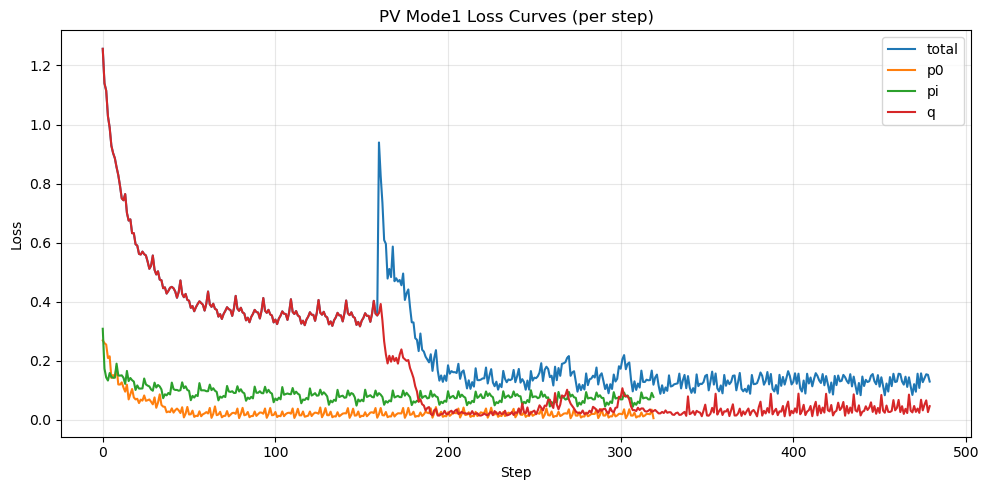

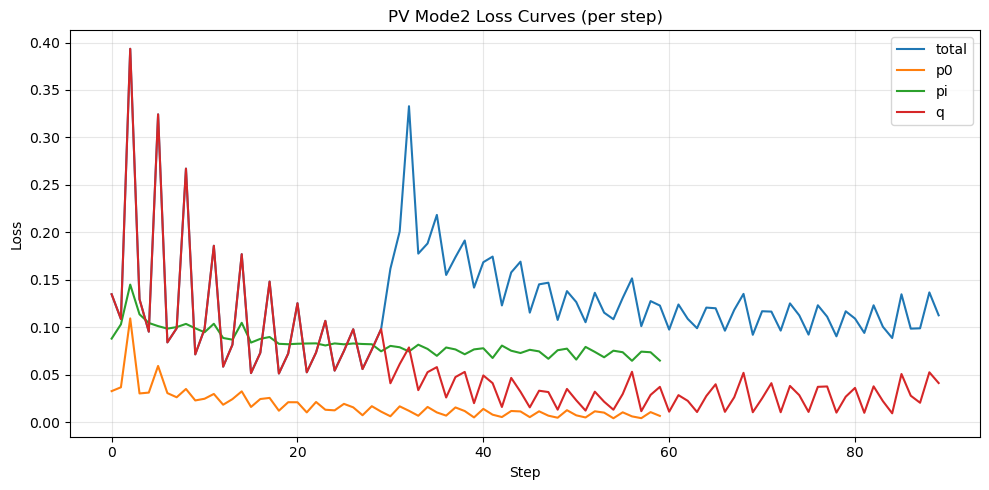

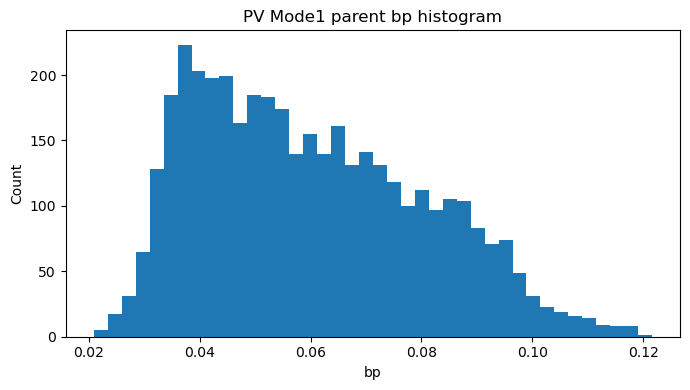

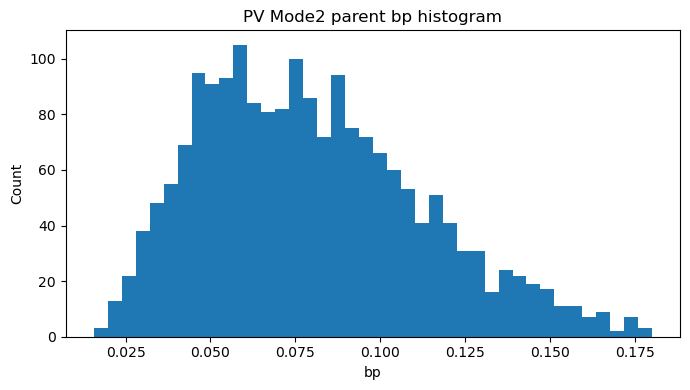

[PV Mode1] grid setup: b in [0.0001057, 0.9998], z in [-2.859, 2.945], ETA/i/x/Hatcf/LnKF means = (0.033, 0.2496, -2.001, -2.001, 4)
[PV Mode2] grid setup: b in [0, 0.9976], z in [-3.336, 2.507], ETA/i/x/Hatcf/LnKF means = (0.03789, 0.2562, -1.994, -1.17, 3.154)


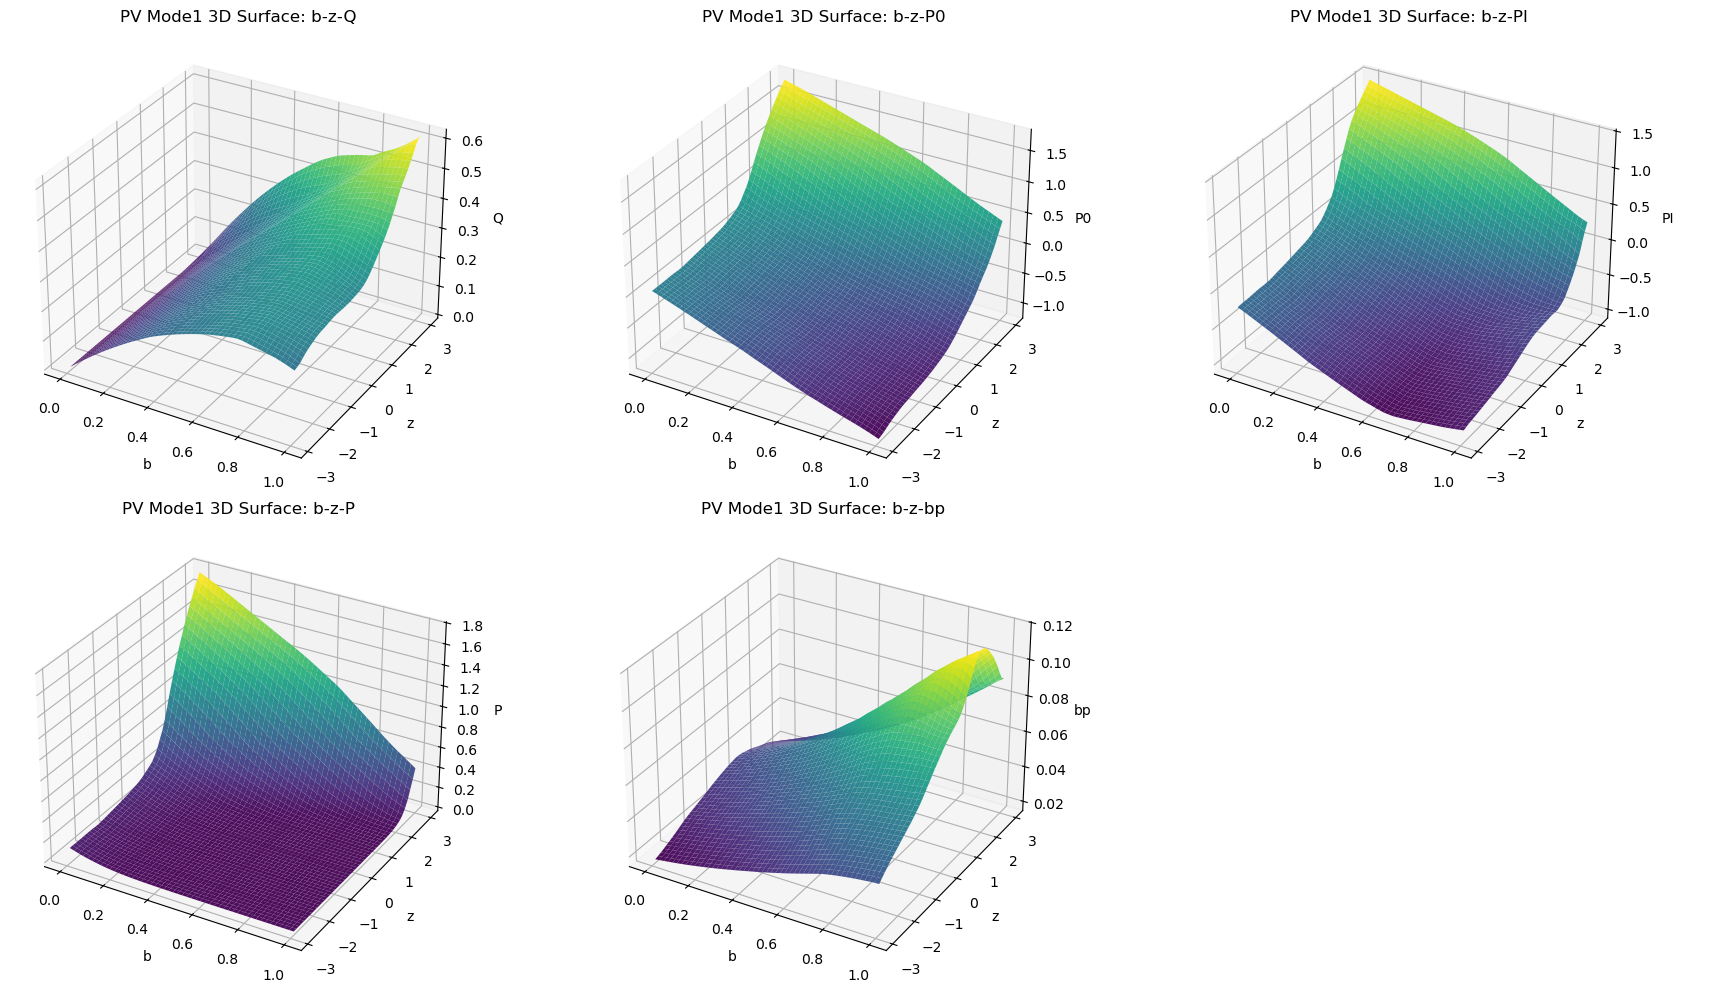

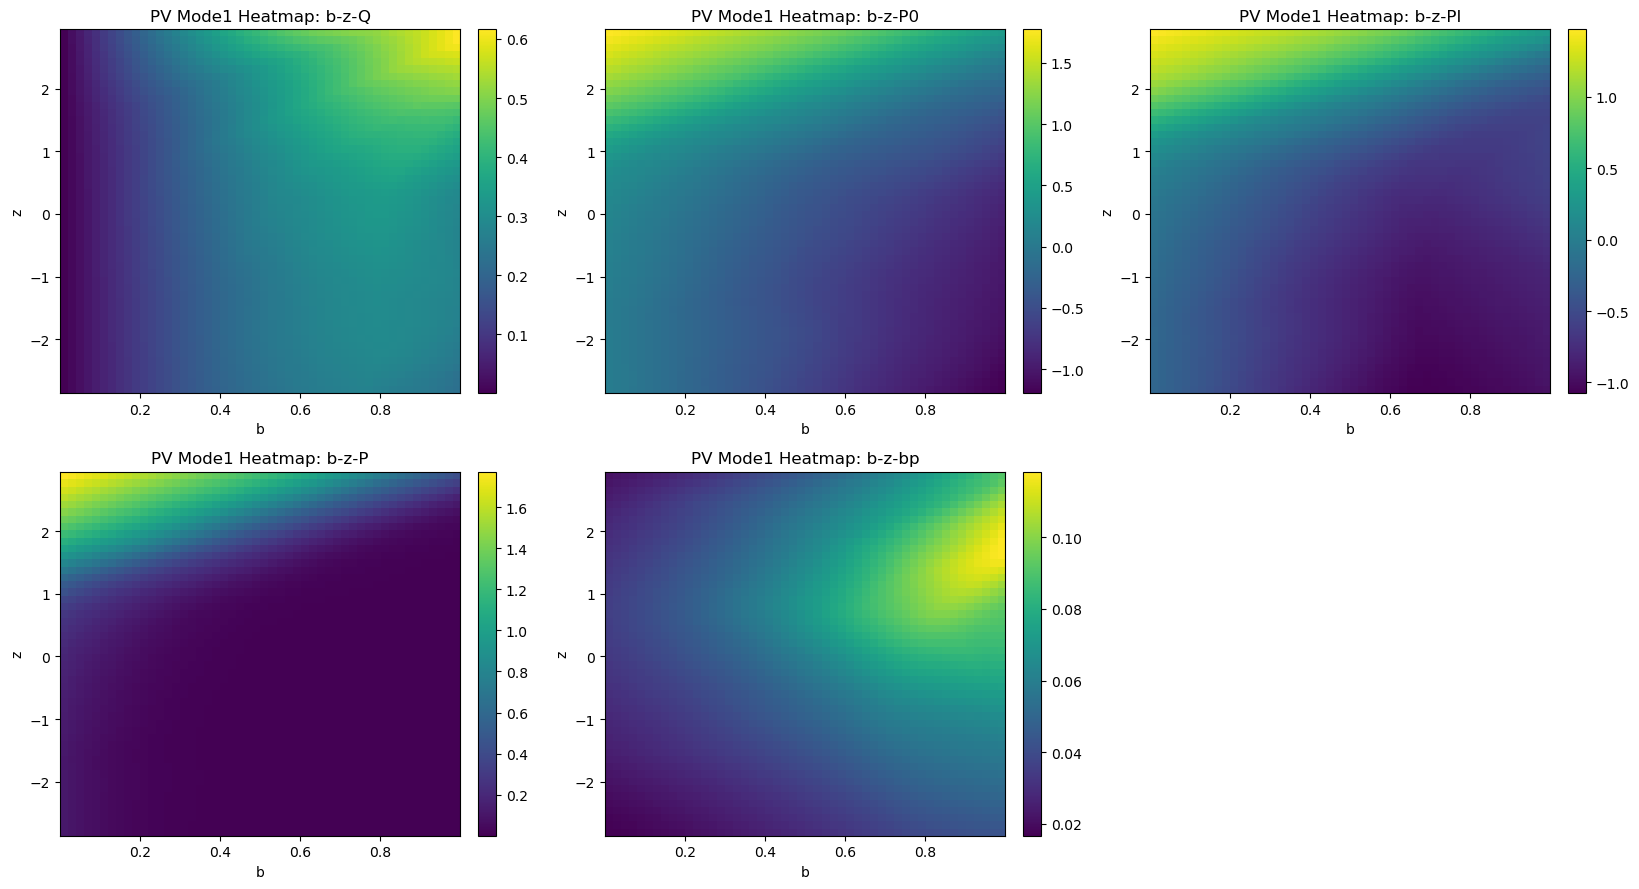

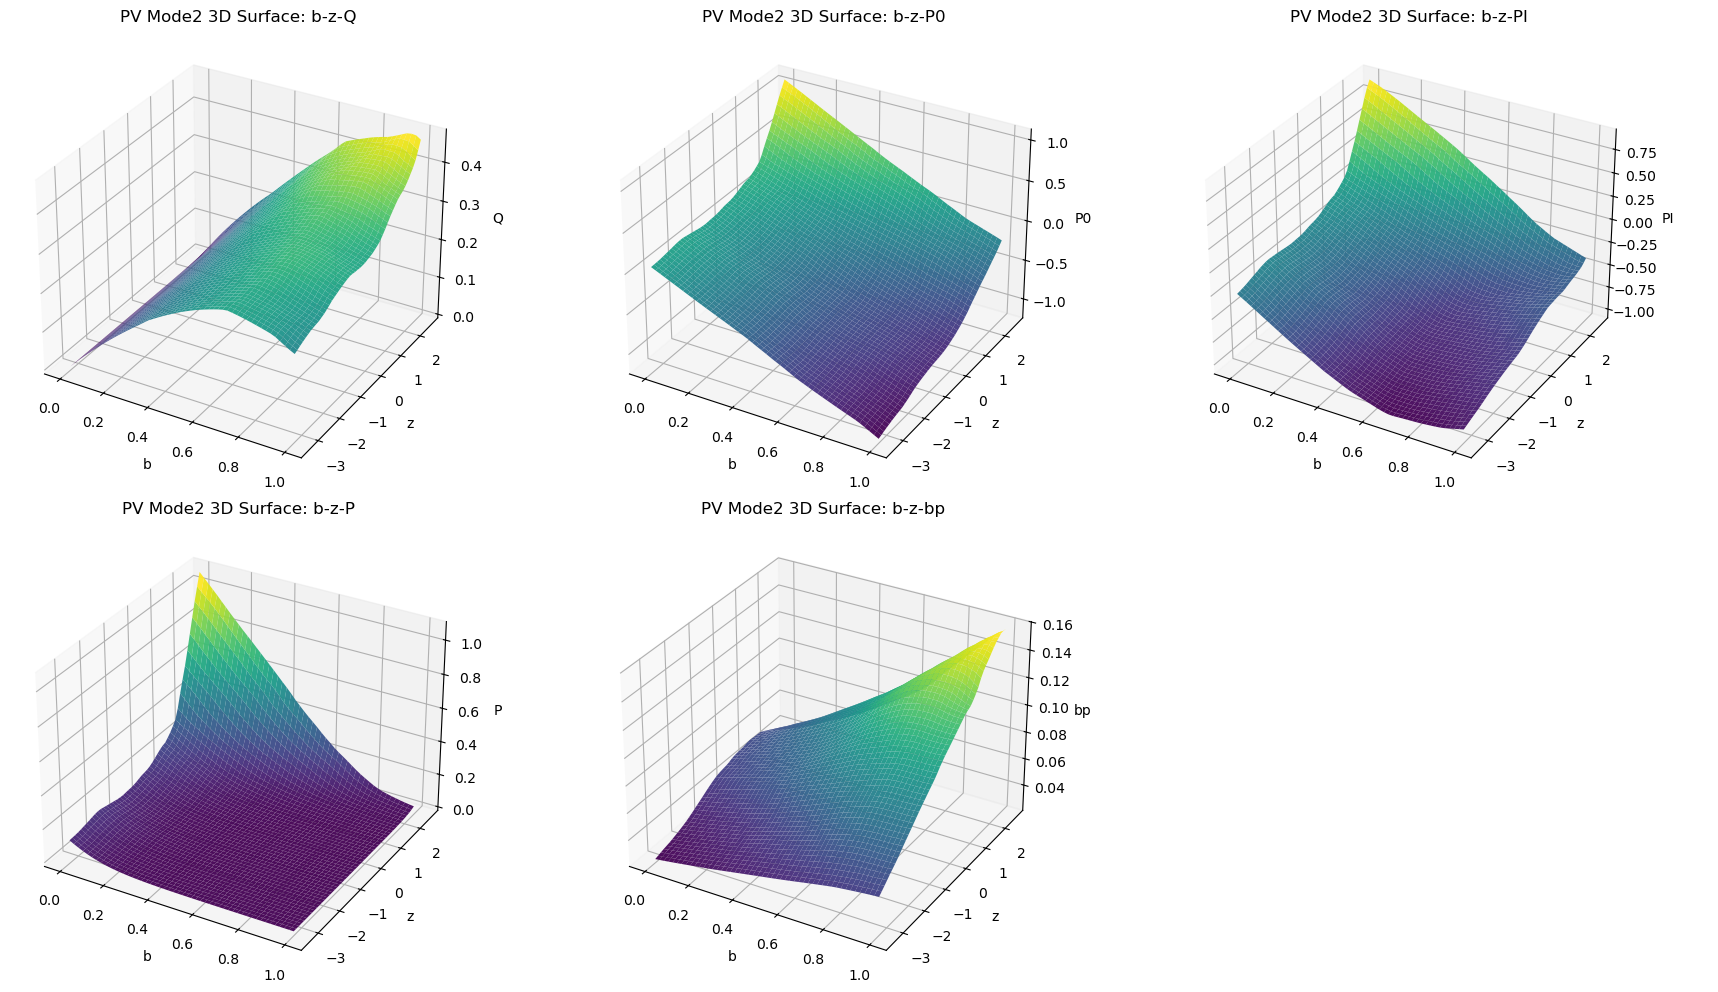

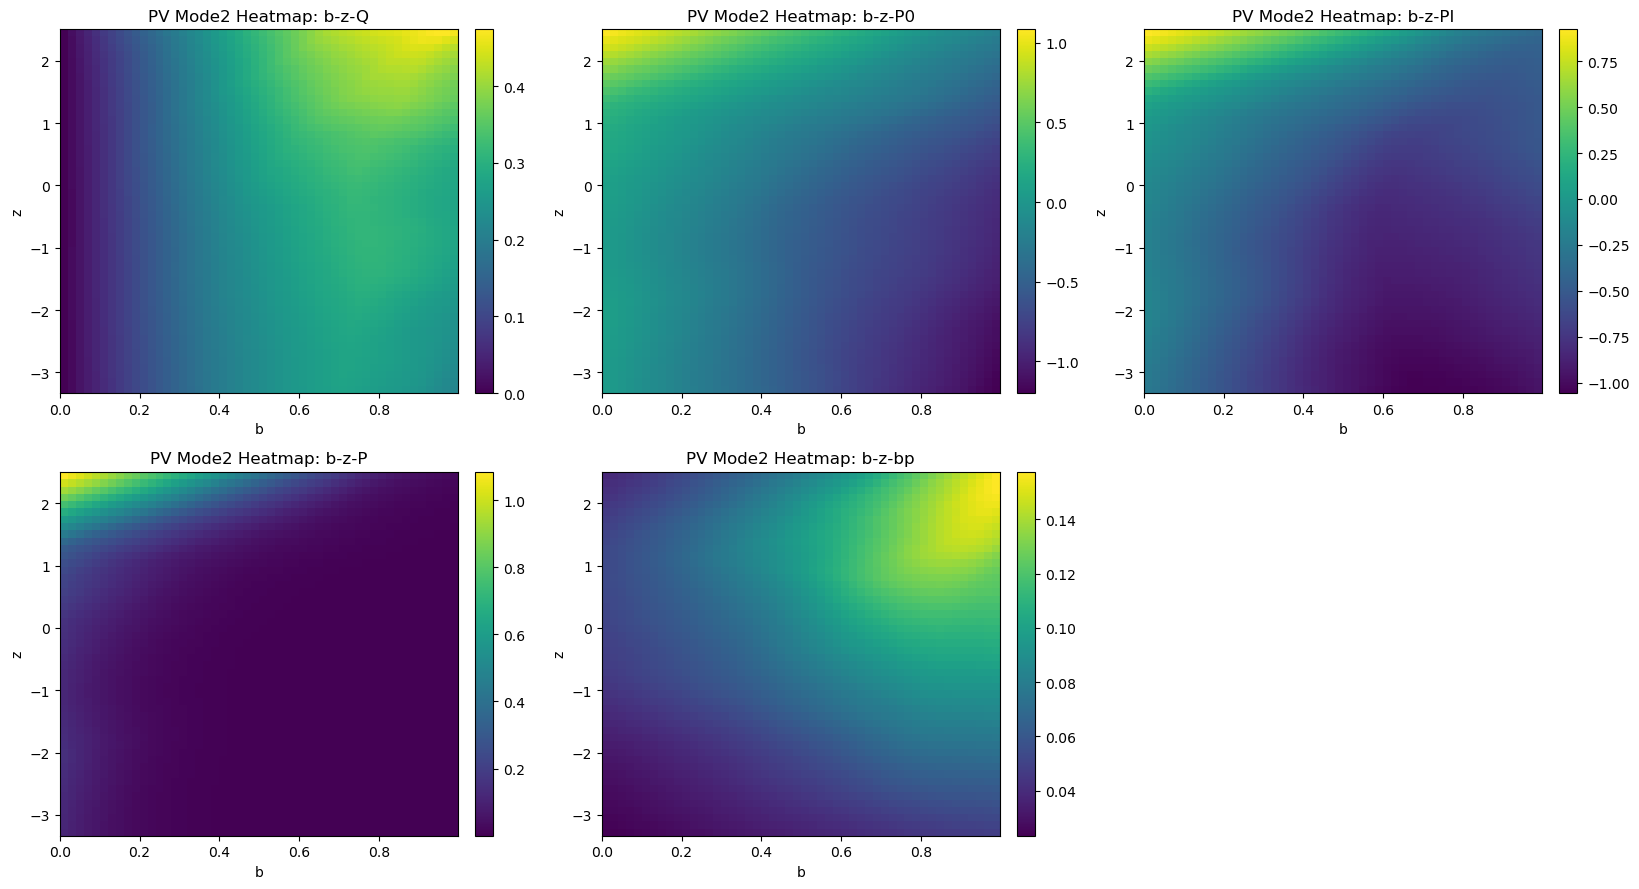

In [22]:
pv_parent_mode1 = collect_policy_parent_outputs(df_pv_mode1, tag='PV Mode1')
pv_parent_mode2 = collect_policy_parent_outputs(df_pv_mode2, tag='PV Mode2')

plot_pv_loss_curves(pv_mode1_loss_history, tag='PV Mode1')
plot_pv_loss_curves(pv_mode2_loss_history, tag='PV Mode2')

plot_bp_hist(pv_parent_mode1, tag='PV Mode1')
plot_bp_hist(pv_parent_mode2, tag='PV Mode2')

pv_grid_mode1 = build_policy_grid_outputs(df_pv_mode1, tag='PV Mode1', grid_n=50)
pv_grid_mode2 = build_policy_grid_outputs(df_pv_mode2, tag='PV Mode2', grid_n=50)

plot_bz_surface_and_heatmap_from_grid(pv_grid_mode1, tag='PV Mode1')
plot_bz_surface_and_heatmap_from_grid(pv_grid_mode2, tag='PV Mode2')



## 5) 3-Episode Quick Test

In [25]:
# 3-episode quick test（ep0: sdf1->pv->sdf2->(fc2), ep>0: pv->sdf2->(fc2)）

quick_n_episodes = 3
quick_epochs = 5
quick_n_paths = 120
quick_n_samples = 1200
quick_horizon = 40
quick_batch_size = 256
quick_enable_fc2 = False  # 可选：False 时跳过 fc2

quick_models = build_models(device)
quick_optimizers = build_optimizers(quick_models)

quick_hp = HyperParams(
    epochs=quick_epochs,
    batch_size=quick_batch_size,
    n_samples=quick_n_samples,
    n_paths=quick_n_paths,
)
quick_hp.lr = 1e-3
quick_hp.min_lr = 1e-6
quick_hp.max_steps = 10000
quick_hp.fc1_recon_weight = 1.0
quick_hp.sdf_stage1_lr = 1e-4
quick_hp.sdf_stage1_moment_weight = 5.0
quick_hp.sdf_moment_weight = 1.0

quick_episode = Episode(
    models=quick_models,
    optimizers=quick_optimizers,
    config=Config,
    hyperparams=quick_hp,
    device=device,
    episode_id=0,
)

def stage_total_loss(stage_summary: dict) -> float:
    vals = []
    if not isinstance(stage_summary, dict):
        return float('nan')
    for mod_summary in stage_summary.values():
        if isinstance(mod_summary, dict):
            final_losses = mod_summary.get('final_losses', {})
            if isinstance(final_losses, dict) and 'total' in final_losses:
                try:
                    vals.append(float(final_losses['total']))
                except Exception:
                    pass
    return float(np.mean(vals)) if vals else float('nan')

quick_results = []
quick_rows = []

for ep in range(quick_n_episodes):
    print(f"\n===== QUICK EPISODE {ep} =====")
    quick_episode.episode_id = ep

    # ep0 需要 sdf1；ep>0 按你的要求从 pv 开始
    if ep == 0:
        stage_order = [('sdf1', ['sdf_fc1']), ('pv', ['policy_value']), ('sdf2', ['sdf_fc1'])]
    else:
        stage_order = [('pv', ['policy_value']), ('sdf2', ['sdf_fc1'])]
    if quick_enable_fc2:
        stage_order.append(('fc2', ['fc2']))

    data_kwargs = {
        'n_samples': quick_hp.n_samples,
        'n_paths': quick_hp.n_paths if ep == 0 else min(100, quick_hp.n_paths),
        'group_size': 2 if ep == 0 else Config.SIMULATE_GROUP_SIZE,
        'n_branches': Config.BRANCH_NUM,
    }
    simulate_kwargs = {'horizon': quick_horizon} if ep > 0 else {}

    ep_summary = {}
    for stage_name, stage_modules in stage_order:
        print(f"[ep{ep}] stage={stage_name}, modules={stage_modules}")
        summary = quick_episode.run_episode(
            n_epochs=quick_hp.epochs,
            batch_size=quick_hp.batch_size,
            log_interval=20,
            train_modules=stage_modules,
            simulate_kwargs=simulate_kwargs,
            **data_kwargs,
        )
        module_summaries = summary.get('module_summaries', summary)
        ep_summary[stage_name] = module_summaries

        t_loss = stage_total_loss(module_summaries)
        quick_rows.append({
            'episode': ep,
            'stage': stage_name,
            'total_loss_mean': t_loss,
            'is_finite': bool(np.isfinite(t_loss)),
        })

    quick_results.append(ep_summary)

quick_df = pd.DataFrame(quick_rows)
print('\nQuick test stage-level summary:')
display(quick_df)

nan_rows = quick_df[~quick_df['is_finite']]
if len(nan_rows) == 0:
    print('[OK] All stage total losses are finite in quick test.')
else:
    print('[WARN] Non-finite stage losses detected:')
    display(nan_rows)



===== QUICK EPISODE 0 =====
[ep0] stage=sdf1, modules=['sdf_fc1']


SDF/FC1 Epoch 5/5: 100%|██████████| 1/1 [00:00<00:00, 210.94it/s]


[ep0] stage=pv, modules=['policy_value']


Policy/Value Epoch 5/5: 100%|██████████| 2/2 [00:00<00:00,  8.05it/s]


[ep0] stage=sdf2, modules=['sdf_fc1']


...

Simulation completed: 3514873 firm records, 12000 macro records
[ep1] stage=sdf2, modules=['sdf_fc1']
Running episode with SimulateTS for data generation and training


Simulating paths: 100%|██████████| 100/100 [02:22<00:00,  1.42s/it]


Simulation completed: 3510199 firm records, 12000 macro records

===== QUICK EPISODE 2 =====
[ep2] stage=pv, modules=['policy_value']
Running episode with SimulateTS for data generation and training


Policy/Value Epoch 1/5:  39%|███▉      | 1712/4363 [02:47<04:19, 10.20it/s]


KeyboardInterrupt: 